# Testing ASP

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:

from train import ASP
import json

# Variables that need to be set
data = 'spec_train.csv' # Data file
model_path = None #'checkpoints/checkpoint_152.pt' # Path for checkpoint if using
config_path = 'config.json' # Config file

# Loading config file
with open(config_path, "r") as f:
    config = json.load(f)
    
#Instantiating & fitting Absorption Spectrum Predictor
asp = ASP(model=model_path,input_data=data,**config)
asp.fit()

/home/matthew/miniforge3/envs/asp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Model architecture: feature dimensions, no. hidden layers, output dimensions
132, 6, 40
Running on compute device: cuda
Model size: 79672 parameters



ElementProperty: 100%|██████████████████████████████████████████████████████████| 10563/10563 [00:09<00:00, 1063.32it/s]


Epoch: 0/500 --- train mae: 9.83e+04 val mae: 9.96e+04
Epoch: 19/500 --- train mae: 7.5e+04 val mae: 7.77e+04
Epoch: 39/500 --- train mae: 8.04e+04 val mae: 8.37e+04
Epoch: 59/500 --- train mae: 7.17e+04 val mae: 7.56e+04
Epoch 79 failed to improve.
Discarded: 1/20 weight updates
Epoch: 79/500 --- train mae: 7.27e+04 val mae: 7.57e+04
Epoch 99 failed to improve.
Discarded: 2/20 weight updates
Epoch: 99/500 --- train mae: 7.61e+04 val mae: 7.84e+04
Epoch: 119/500 --- train mae: 7.07e+04 val mae: 7.39e+04
Epoch 139 failed to improve.
Discarded: 3/20 weight updates
Epoch: 139/500 --- train mae: 7.75e+04 val mae: 8.08e+04
Epoch: 159/500 --- train mae: 1e+05 val mae: 1.06e+05
Epoch: 179/500 --- train mae: 7.46e+04 val mae: 7.82e+04
Epoch: 199/500 --- train mae: 7e+04 val mae: 7.41e+04
Epoch 219 failed to improve.
Discarded: 4/20 weight updates
Epoch: 219/500 --- train mae: 7.09e+04 val mae: 7.44e+04
Epoch 239 failed to improve.
Discarded: 5/20 weight updates
Epoch: 239/500 --- train mae: 7.

In [3]:
formulae, pred, act=asp.predict(data='spec_test.csv')

ElementProperty: 100%|█████████████████████████████████████████████████████████████| 1174/1174 [00:01<00:00, 990.35it/s]


In [4]:
with open('loss_stats.json','r') as file:
    stats = json.load(file)

In [5]:
xs = np.linspace(0,500,26)

Text(0, 0.5, 'MAE')

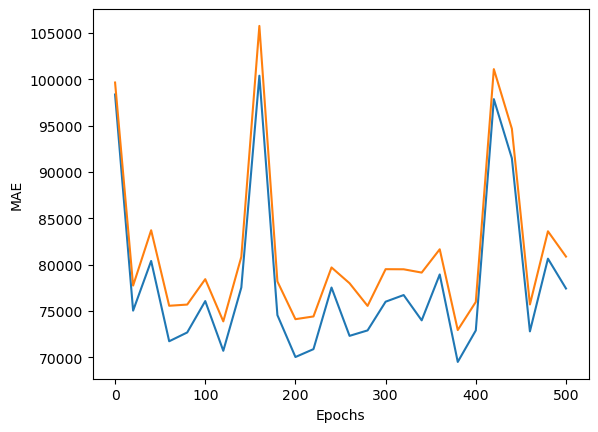

In [6]:
plt.plot(xs,stats['train'])
plt.plot(xs,stats['val'])
plt.xlabel('Epochs')
plt.ylabel('MAE')

In [12]:
form_mat = np.reshape(formulae,(-1,1))

In [13]:
form_pred = np.append(form_mat,pred,axis=-1)

In [17]:
headers = ['formula']
for i in range(40):
    energy = 'E'+str(i+1)
    headers.append(energy)

In [18]:
df = pd.DataFrame(form_pred, columns = headers)

In [ ]:
#d = {'formula': np.reshape(formulae,(-1)), 'pred': np.reshape(pred,(-1)), 'act': np.reshape(act,(-1))}
#df = pd.DataFrame.from_dict(d)
#df.to_csv('SLME_preds.csv',index=False)

In [19]:
df

,formula,E1,E2,E3,E4,E5,E6,E7,E8,E9,...,E31,E32,E33,E34,E35,E36,E37,E38,E39,E40
0,SrTa2Bi2O9,-483.06337,-1972.385478,-3701.853006,-5275.802163,-7535.097225,-10012.556791,-12494.146926,-15096.779865,-18506.164271,...,424365.329134,469721.871813,514650.278038,560651.072572,605909.012709,651360.613202,695577.399737,734895.176555,769297.443544,801636.246151
1,CdSiN2,30.58127,61.566847,508.975321,1383.653747,1830.197093,1743.249745,1940.009123,2374.443422,3738.742968,...,286235.813346,313130.176011,339640.330662,366862.62836,394711.015393,423172.237652,451713.45046,478391.798532,502746.510987,526057.06564
2,LiBi(BO3)2,-40.351326,-193.455963,129.362009,722.523044,534.37473,-648.795684,-1711.187575,-3098.963084,-4473.477528,...,138385.106008,161270.680274,183686.475547,208336.111071,233870.411925,261079.766568,288881.431095,314522.276009,337850.021192,361001.544115
3,LiVSiO4,-81.692091,-403.774005,-374.53726,-70.499164,-433.128594,-1452.425198,-2417.929405,-3492.578948,-4454.82535,...,217727.363951,244770.103106,271383.645129,299695.673003,328581.17213,358632.920264,388852.394571,416728.414972,441806.969837,466232.402698
4,Li3Co(NO2)6,190.19767,688.834514,1963.131568,3642.662079,4694.124163,4756.077853,4943.191648,5049.382656,5909.684691,...,108867.942995,125432.68569,141515.780655,159490.286851,178886.773438,200017.927862,222052.768604,243140.542496,262937.849484,282707.902109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1169,Bi2SeO6,-454.366922,-1823.674117,-3344.029861,-4624.288269,-6582.020964,-8796.312826,-11076.356257,-13392.34647,-16586.929632,...,440022.098384,486228.707428,531851.501428,578527.886888,624467.941523,670731.899018,715478.837188,755134.541138,790206.069717,822849.170701
1170,Rb2Ti(GeO3)3,-262.191496,-1083.793589,-1727.08432,-2229.498851,-3633.217837,-5869.731146,-8126.574764,-10856.157184,-14313.558657,...,185831.803187,215857.436383,245396.295237,277410.93059,309740.799399,343596.090218,377563.296198,408230.344754,435430.353649,462157.056883
1171,CrSbTeO6,-194.503335,-826.995285,-1308.478814,-1481.783658,-2238.728282,-3440.053287,-4535.638081,-5581.718846,-6577.529144,...,326680.303532,360918.87979,394707.834727,429584.553312,464549.518176,500118.168707,535211.561328,567130.54763,595683.474478,622815.649007
1172,NaBiS2,-236.92313,-990.627378,-1913.416159,-2299.117525,-2827.673062,-3034.224507,-2891.231433,-1849.159309,194.681445,...,584650.849918,629476.180068,673758.981787,717003.795472,759571.48344,801050.227833,840949.535649,877462.868599,909959.570333,939597.753593


In [20]:
df.to_csv('Spec_preds.csv',index=False)